# CSI Genome: The Contamination Detective
**Project 07 · BDA-2405 · Astana IT University**  
**Abylaikhan Torekhan and Kuanysh Bakizhan**

This notebook contains the complete analysis code. Read the eight tasks in handbook order, or choose **Restart Kernel and Run All Cells**.

- `MODE = "full"` analyses the 3,006 real assemblies used in the report. The first run downloads about 1 GB; allow about 6 GB of free space. Cached computation takes a few minutes.
- `MODE = "test"` runs the same methods on 13 bundled assemblies and tiny read samples, without internet. This checks the workflow; it cannot reproduce archive-wide rates.
- Install Python 3.12 and `requirements.lock.txt` before opening the notebook. Open it from the repository folder. Metadata, reference sequences and recorded review decisions remain normal data files.

The saved full-run result is **246 / 3,006 flagged (8.18%)**. A flag requests review; it does not prove contamination.

In [1]:
from pathlib import Path
import os, csv, gzip, hashlib, json, math, re, resource, shutil, time, urllib.parse, urllib.request, zipfile
import collections, itertools
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import mappy
from IPython.display import display, Image
# Choose 'full' for the report dataset, or 'test' for a quick offline run.
MODE = 'full'
MODE = os.environ.get('CSI_GENOME_MODE', MODE)
REFRESH_METADATA = False
assert MODE in {'test', 'full'}
assert Path('config/assemblies.csv').exists(), 'Open the notebook from the repository folder.'
RAW = Path('data/test' if MODE == 'test' else 'data/raw')
OUT = Path('results_test' if MODE == 'test' else 'results')
METADATA = Path('data/test/assemblies.csv' if MODE == 'test' else 'config/assemblies.csv')
RUNS = Path('data/test/reads.csv' if MODE == 'test' else 'config/reads.csv')
SHORT_LIMIT = 100 if MODE == 'test' else 10000
LONG_LIMIT = 20 if MODE == 'test' else 2000
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 160, 'axes.spines.top': False, 'axes.spines.right': False})
print('Mode:', MODE, '| Results:', OUT)

Mode: full | Results: results


## Task 1. Define contamination categories

| Category | Meaning and laboratory origin |
|---|---|
| Foreign organism | Host DNA, another microbe or reagent DNA enters the sample, or is included in the assembly. |
| Vector | Cloning-plasmid sequence remains in the sample. Engineered strains may contain it intentionally. |
| Adapter | A library-preparation sequence remains after read-through, incomplete trimming or assembly. |
| Index hopping | A read receives another sample's index during pooled sequencing and is assigned to the wrong library. |
| Sample swap or mislabel | The specimen, organism label or archive link is mixed up during laboratory work or submission. |

**HGT (horizontal gene transfer)** is real movement of DNA between organisms. An internal foreign block with long flanks may be HGT or an intended construct. Neither unusual GC nor a foreign match alone proves an error.

We use a deliberately small panel: E. coli, Ralstonia pickettii, mouse mitochondrial DNA and an Arabidopsis chloroplast. These represent possible laboratory, reagent, animal-host and plant-host sources. UniVec_Core covers vector and related technical sequence.

## Task 2. Select the archive slice and retrieve data

The fixed 29 September 2026 snapshot contains **3,006 GenBank Mollicutes assemblies (taxid 31969)**. Small genomes make this group manageable; animal and plant hosts also give a biological reason to check for host DNA. FASTA records, versioned accessions, BioSample and BioProject IDs are recorded in `config/`.

The small helper functions below read FASTA/CSV files and compute GC content. They are used by later tasks. All analysis functions are defined inside this notebook.

In [2]:
def fasta(text):
    name, parts = (None, [])
    for line in text.splitlines():
        if line.startswith('>'):
            if name:
                yield (name, ''.join(parts).upper())
            name, parts = (line[1:].split()[0], [])
        else:
            parts.append(line.strip())
    if name:
        yield (name, ''.join(parts).upper())

def genomes(raw):
    for path in sorted(Path(raw).glob('genomes/*.zip')):
        with zipfile.ZipFile(path) as z:
            for name in z.namelist():
                if name.endswith('.fna'):
                    yield (name.split('/')[-2], list(fasta(z.read(name).decode())))

def read_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

def write_csv(path, rows, fields=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w') as f:
        w = csv.DictWriter(f, fieldnames=fields or list(rows[0]))
        w.writeheader()
        w.writerows(rows)

def gc(s):
    n = sum((s.count(x) for x in 'ACGT'))
    return (s.count('G') + s.count('C')) / n if n else 0

def rc(s):
    return s.translate(str.maketrans('ACGT', 'TGCA'))[::-1]

### Download the fixed inputs
Existing files are reused. Downloads use temporary files and record the URL, date and SHA-256 checksum. Read files contain only a limited prefix, not the entire sequencing run. The test mode skips network access.

In [3]:
BASE = 'https://api.ncbi.nlm.nih.gov/datasets/v2/genome/download'

def download(url, path, payload=None, records=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.stat().st_size:
        return
    request = urllib.request.Request(url, data=json.dumps(payload).encode() if payload else None, headers={'Content-Type': 'application/json', 'User-Agent': 'CSI-Genome-course-project'})
    temp = path.with_suffix(path.suffix + '.part')
    try:
        with urllib.request.urlopen(request, timeout=180) as response:
            if records:
                with gzip.GzipFile(fileobj=response) as source, gzip.open(temp, 'wb') as out:
                    count = 0
                    for _ in range(records):
                        lines = [source.readline() for _ in range(4)]
                        if not lines[0]:
                            break
                        if not lines[0].startswith(b'@') or not lines[2].startswith(b'+') or len(lines[1].strip()) != len(lines[3].strip()):
                            raise ValueError('Incomplete or invalid FASTQ record')
                        out.writelines(lines)
                        count += 1
                    if not count:
                        raise ValueError('Empty FASTQ')
            else:
                with temp.open('wb') as out:
                    shutil.copyfileobj(response, out)
        temp.replace(path)
    except Exception:
        temp.unlink(missing_ok=True)
        raise
    with open(path.parent / 'downloads.jsonl', 'a') as log:
        log.write(json.dumps({'url': url, 'file': path.name, 'retrieved_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest(), 'first_records': records}) + '\n')

In [4]:
def fetch_data(raw):
    accessions = pd.read_csv('config/assemblies.csv')['accession'].tolist()
    for i in range(0, len(accessions), 150):
        payload = {'accessions': accessions[i:i + 150], 'include_annotation_type': ['GENOME_FASTA']}
        download(BASE, raw / f'genomes/batch_{i // 150:03d}.zip', payload)
    for row in read_csv('config/reads.csv'):
        for url in row['fastq_ftp'].split(';'):
            if row['library_layout'] == 'PAIRED' and (not url.endswith(('_1.fastq.gz', '_2.fastq.gz'))):
                continue
            limit = 2000 if row['purpose'] == 'long_read' else 10000
            download('https://' + url, raw / 'reads' / row['run_accession'] / url.split('/')[-1], records=limit)
    (raw / 'refs').mkdir(parents=True, exist_ok=True)
    for name in ['panel.fasta', 'UniVec_Core.fasta']:
        if not (raw / 'refs' / name).exists():
            shutil.copyfile(Path('data/test/refs') / name, raw / 'refs' / name)
    (raw / '.ready').touch()
if MODE == 'full':
    fetch_data(RAW)
assemblies = pd.read_csv(METADATA)
runs = pd.read_csv(RUNS)
print(len(assemblies), 'assemblies;', len(runs), 'read runs')
display(assemblies[['accession', 'organism', 'biosample', 'bioproject', 'year', 'platform']].head())
display(runs[['run_accession', 'accession', 'platform', 'instrument_model']])

3006 assemblies; 7 read runs


,accession,organism,biosample,bioproject,year,platform
0,GCA_000008305.1,Mesoplasma florum L1,SAMN03081416,PRJNA10650,2004,Unknown
1,GCA_000009845.1,Onion yellows phytoplasma OY-M,SAMD00061121,PRJNA9615,2007,Unknown
2,GCA_000011445.1,Mycoplasma mycoides subsp. mycoides SC str. PG1,SAMEA3138208,PRJNA10616,2007,Unknown
3,GCA_000012225.1,Aster yellows witches'-broom phytoplasma AYWB,SAMN02603687,PRJNA13478,2006,Unknown
4,GCA_000012765.1,Mycoplasma capricolum subsp. capricolum ATCC 2...,SAMN02603434,PRJNA16208,2005,Unknown


,run_accession,accession,platform,instrument_model
0,ERR14335636,GCA_965212735.1,Illumina,NextSeq 500
1,ERR14335635,GCA_965212725.1,Illumina,NextSeq 500
2,DRR504716,GCA_040369795.1,ONT,MinION
3,SRR6082028,GCA_002441935.1,ONT,MinION
4,SRR33330896,GCA_041276565.1,Illumina,Illumina NovaSeq X Plus
5,SRR9681681,GCA_007859615.1,Illumina,Illumina MiSeq
6,SRR28122442,GCA_038024965.1,PacBio,Sequel IIe


### Retrieve metadata and check identifier links
The full NCBI and ENA metadata snapshots are included. The optional refresh below downloads versioned NCBI metadata and ENA run metadata into a separate folder, so current annotations cannot silently replace the study snapshot. Enable it only in full mode if a live refresh is wanted.

We join both ENA BioSample columns to assembly BioSample IDs. Missing links remain missing. Some metagenome assemblies refer to parent samples, which this direct join misses. Failed ANI taxonomy checks are review candidates, not proven sample swaps.

In [5]:
def refresh_metadata():
    out = Path('data/metadata_refresh')
    out.mkdir(parents=True, exist_ok=True)
    accs = [r['accession'] for r in read_csv('config/assemblies.csv')]
    for i in range(0, len(accs), 100):
        url = 'https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/' + ','.join(accs[i:i + 100]) + '/dataset_report?page_size=1000'
        download(url, out / f'assemblies_{i // 100:03d}.json')
        time.sleep(0.4)
    fields = 'run_accession,sample_accession,secondary_sample_accession,study_accession,instrument_platform,instrument_model,read_count,base_count,fastq_ftp,first_public'
    url = 'https://www.ebi.ac.uk/ena/portal/api/search?' + urllib.parse.urlencode(dict(result='read_run', query='tax_tree(31969)', fields=fields, format='tsv', limit=0))
    download(url, out / 'ena_runs.tsv')
    print('Refreshed metadata in', out)
if REFRESH_METADATA and MODE == 'full':
    refresh_metadata()

In [6]:
ena = pd.read_csv('config/ena_runs.tsv', sep='\t', dtype=str).fillna('')
links = []
for row in assemblies.itertuples():
    if pd.isna(row.biosample):
        continue
    matches = ena[(ena.sample_accession == row.biosample) | (ena.secondary_sample_accession == row.biosample)]
    for run in matches.itertuples():
        links.append({'assembly': row.accession, 'biosample': row.biosample, 'run': run.run_accession, 'ena_sample': run.sample_accession, 'ena_secondary_sample': run.secondary_sample_accession, 'platform': run.instrument_platform})
write_csv(OUT / 'archive_links.csv', links, ['assembly', 'biosample', 'run', 'ena_sample', 'ena_secondary_sample', 'platform'])
print('Assemblies directly linked to ENA:', len({row['assembly'] for row in links}))
print('Missing or unrecognised platform labels:', (assemblies.platform == 'Unknown').sum())
print('Failed ANI taxonomy checks:', (assemblies.ani_status == 'Failed').sum())

Assemblies directly linked to ENA: 212
Missing or unrecognised platform labels: 173
Failed ANI taxonomy checks: 7


## Task 3. Compare signatures by platform and era

We first search every contig in both orientations for exact adapter motifs and calculate its GC difference from the assembly. This supplies an initial, clearly defined technical signature for platform/year comparisons. The broader foreign/vector screen is added in Task 6, and all categories are compared in Task 7.

Only exact 19-21 bp motifs are detected. A match is saved with its assembly ID, contig ID and **1-based inclusive coordinates**. Contigs of at least 1 kb are also saved for the reference alignment in Task 6.

In [7]:
ADAPTERS = {'TruSeq': 'AGATCGGAAGAGCACACGTCT', 'TruSeq_R2': 'AGATCGGAAGAGCGTCGTGTA', 'Nextera': 'CTGTCTCTTATACACATCT', 'BGI': 'AAGTCGGAGGCCAAGCGGTC'}

def scan(raw, out, metadata):
    start = time.perf_counter()
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    meta = {r['accession']: r for r in read_csv(metadata)}
    motifs = {seq: name for name, s in ADAPTERS.items() for seq in (s, rc(s))}
    regex = re.compile('|'.join(motifs))
    rows, flags, candidates = ([], [], [])
    with (out / 'candidates.fasta').open('w') as cf:
        for accession, contigs in genomes(raw):
            total = sum((len(s) for _, s in contigs))
            genome_gc = sum((s.count('G') + s.count('C') for _, s in contigs)) / max(1, total)
            adapter_count = outliers = 0
            for cid, s in contigs:
                delta = abs(gc(s) - genome_gc)
                hits = list(regex.finditer(s))
                for h in hits:
                    adapter_count += 1
                    flags.append(dict(accession=accession, contig=cid, category='Adapter', start=h.start() + 1, end=h.end(), length=len(s), identity=1.0, coverage=len(h.group()) / len(s), source=motifs[h.group()], score=4, status='technical_match', gc_delta=delta))
                if len(s) >= 1000:
                    qid = f'q{len(candidates):06d}'
                    candidates.append(dict(qid=qid, accession=accession, contig=cid, length=len(s), gc_delta=delta))
                    cf.write(f'>{qid}\n{s}\n')
                    outliers += delta >= 0.12
            rows.append(dict(**meta[accession], bp=total, contigs=len(contigs), gc=genome_gc, adapter_matches=adapter_count, gc_outlier_contigs=outliers))
    write_csv(out / 'assemblies.csv', rows)
    write_csv(out / 'adapter_hits.csv', flags, ['accession', 'contig', 'category', 'start', 'end', 'length', 'identity', 'coverage', 'source', 'score', 'status', 'gc_delta'])
    write_csv(out / 'candidates.csv', candidates)
    (out / 'scan_runtime.json').write_text(json.dumps({'seconds': time.perf_counter() - start, 'assemblies': len(rows), 'bp': sum((r['bp'] for r in rows)), 'contigs': sum((r['contigs'] for r in rows)), 'peak_rss_os_units': resource.getrusage(resource.RUSAGE_SELF).ru_maxrss}, indent=2))
    print('Scanned', len(rows), 'assemblies;', len(flags), 'exact adapter matches', flush=True)

In [8]:
scan(RAW, OUT, METADATA)
assembly_stats = pd.read_csv(OUT / 'assemblies.csv')
adapter_hits = pd.read_csv(OUT / 'adapter_hits.csv')
assembly_stats['adapter'] = assembly_stats.accession.isin(adapter_hits.accession)
assembly_stats['era'] = pd.cut(assembly_stats.year, [1990, 2015, 2019, 2022, 2026], labels=['<=2015', '2016-2019', '2020-2022', '2023-2026'])
for column in ['platform', 'era']:
    table = assembly_stats.groupby(column, observed=True).adapter.agg(assemblies='size', flagged='sum')
    table['rate_percent'] = 100 * table.flagged / table.assemblies
    display(table.round(2))
print('Adapter matches:', len(adapter_hits))
display(adapter_hits[['accession', 'contig', 'start', 'end', 'source']].head())

Scanned 3006 assemblies; 7210 exact adapter matches


,assemblies,flagged,rate_percent
platform,,,
Hybrid,111,0,0.00
Long,236,0,0.00
Short,2486,218,8.77
Unknown,173,25,14.45


,assemblies,flagged,rate_percent
era,,,
<=2015,113,3,2.65
2016-2019,303,8,2.64
2020-2022,634,43,6.78
2023-2026,1956,189,9.66


Adapter matches: 7210


,accession,contig,start,end,source
0,GCA_000309405.1,AKIN01000271.1,340,360,TruSeq_R2
1,GCA_000309405.1,AKIN01000150.1,39,59,TruSeq_R2
2,GCA_000309465.1,AKIK01000046.1,7,27,TruSeq_R2
3,GCA_000309485.1,AKIL01000150.1,1110,1130,TruSeq_R2
4,GCA_000309485.1,AKIL01000133.1,17068,17088,TruSeq_R2


**Interpretation.** Adapters come from library chemistry. Short fragments can produce read-through, and fragmented assemblies have more contig ends where technical sequence can remain. However, species, laboratories and assembly methods differ between groups. A higher rate does not show that one instrument caused contamination. Archive release year is not necessarily sequencing year. In test mode these tables describe only the selected 13 assemblies.

## Task 4. Detect short-read artefacts

For each Illumina run we examine the first 10,000 pairs in full mode (100 pairs in test mode). We calculate base quality, GC distribution, exact adapter matches, repeated sequences, poly-G tails and low complexity.

- Low complexity: trinucleotide entropy below 3 bits. AT-rich bacteria can naturally trigger this warning.
- Poly-G: at least ten G bases at the end of a read.
- Trimming: remove the first exact adapter, trim trailing Q<20 bases, discard reads shorter than 50 bases.
- Index hopping screen: both mates must favour the other candidate sample at MAPQ>=30, identity>=98% and query coverage>=90%.

The read function is shared with Task 5. Its `read_kind` argument selects short or long reads; the long-read branch performs the split-alignment check described there.

In [9]:
def fastq(path, n):
    with gzip.open(path, 'rt') as f:
        for _ in range(n):
            name = f.readline().strip()
            if not name:
                return
            seq = f.readline().strip()
            plus = f.readline()
            qual = f.readline().strip()
            if not name.startswith('@') or not plus.startswith('+') or len(seq) != len(qual):
                raise ValueError('Invalid FASTQ')
            yield (name[1:].split()[0], seq, qual)

def entropy(s):
    counts = collections.Counter((s[i:i + 3] for i in range(len(s) - 2)))
    n = sum(counts.values())
    return -sum((c / n * math.log2(c / n) for c in counts.values())) if n else 0

In [10]:
def analyse_reads(raw, out, runs_file, panel_file, short_limit, long_limit, read_kind):
    start = time.perf_counter()
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    runs = read_csv(runs_file)
    runs = [r for r in runs if (r['purpose'] == 'long_read') == (read_kind == 'long')]
    wanted = {r['accession'] for r in runs}
    own = {}
    for acc, contigs in genomes(raw):
        if acc in wanted:
            own[acc] = contigs
    panel = Path(panel_file).read_text()
    summary = []
    hist = []
    cycle = []
    splits = []
    pool = []
    pairs = [r for r in runs if r['purpose'] == 'index_hopping']
    poolfa = out / 'pooled.fasta'
    with poolfa.open('w') as f:
        for r in pairs:
            for cid, s in own[r['accession']]:
                f.write(f">{r['run_accession']}|{cid}\n{s}\n")
    poolindex = mappy.Aligner(str(poolfa), preset='sr') if pairs else None
    for r in runs:
        run = r['run_accession']
        long = r['purpose'] == 'long_read'
        n = long_limit if long else short_limit
        preset = 'map-pb' if r['platform'] == 'PacBio' and 'RS II' in r['instrument_model'] else 'map-hifi' if r['platform'] == 'PacBio' else 'map-ont' if long else 'sr'
        ref = out / f'{run}.reference.fasta'
        with ref.open('w') as f:
            for cid, s in own[r['accession']]:
                f.write(f'>native|{cid}\n{s}\n')
            f.write(panel)
        index = mappy.Aligner(str(ref), preset=preset, best_n=5)
        paths = sorted((Path(raw) / 'reads' / run).glob('*.fastq.gz'))
        paths = [p for p in paths if p.name.endswith(('_1.fastq.gz', '_2.fastq.gz'))] if not long else paths[:1]
        lengths = []
        qualities = []
        gcs = []
        identities = []
        indels = []
        seen = set()
        duplicates = adapter = low = polyg = mapped = chim = 0
        trimmed = discarded = 0
        retained_q = []
        qs = collections.defaultdict(list)
        cross = paircount = 0
        for file in paths:
            for name, s, q in fastq(file, n):
                lengths.append(len(s))
                gcs.append(gc(s))
                qualities.append(np.mean([ord(x) - 33 for x in q]))
                low += entropy(s) < 3
                duplicates += s in seen
                seen.add(s)
                polyg += s.endswith('G' * 10)
                adapter += any((x in s for x in ADAPTERS.values()))
                for pos, char in enumerate(q):
                    if not long:
                        qs[pos].append(ord(char) - 33)
                if not long:
                    cut = min([s.find(x) for x in ADAPTERS.values() if x in s] or [len(s)])
                    clean = s[:cut]
                    quality = q[:cut]
                    while quality and ord(quality[-1]) - 33 < 20:
                        clean = clean[:-1]
                        quality = quality[:-1]
                    trimmed += len(clean) < len(s)
                    if len(clean) < 50:
                        discarded += 1
                        continue
                    retained_q.extend((ord(x) - 33 for x in quality))
                    s = clean
                hits = list(index.map(s, cs=True))
                good = [h for h in hits if h.mapq >= 20 and h.blen >= 100]
                if good:
                    h = max(good, key=lambda h: h.mlen)
                    mapped += 1
                    identities.append(h.mlen / h.blen)
                    insdel = sum((k for k, op in h.cigar or [] if op in [1, 2]))
                    errors = h.blen - h.mlen
                    if errors:
                        indels.append(insdel / errors)
                if long:
                    found = False
                    for h1, h2 in itertools.combinations(good, 2):
                        overlap = max(0, min(h1.q_en, h2.q_en) - max(h1.q_st, h2.q_st))
                        different = h1.ctg.startswith('native|') != h2.ctg.startswith('native|')
                        if different and min(h1.q_en - h1.q_st, h2.q_en - h2.q_st) >= 300 and (overlap <= 50):
                            chim += 1
                            found = True
                            splits.append(dict(run=run, read=name, left=h1.ctg, right=h2.ctg, left_start=h1.q_st + 1, left_end=h1.q_en, right_start=h2.q_st + 1, right_end=h2.q_en))
                            break
        if r['purpose'] == 'index_hopping' and len(paths) == 2:
            for left, right in zip(fastq(paths[0], n), fastq(paths[1], n), strict=True):
                paircount += 1
                assigned = []
                for _, s, _ in [left, right]:
                    hs = [h for h in poolindex.map(s) if h.mapq >= 30 and h.mlen / max(1, h.blen) >= 0.98 and (h.q_en - h.q_st >= 0.9 * len(s))]
                    assigned.append(hs[0].ctg.split('|')[0] if hs else '')
                cross += bool(assigned[0] and assigned[0] == assigned[1] and (assigned[0] != run))
            pool.append(dict(run=run, pairs=paircount, cross_sample_pairs=cross, fraction=cross / max(1, paircount)))
        size = len(lengths)
        summary.append(dict(run=run, assembly=r['accession'], platform=r['platform'], model=r['instrument_model'], preset=preset, reads=size, median_length=float(np.median(lengths)), mean_phred=float(np.mean(qualities)), adapter_fraction=adapter / size, low_complexity_fraction=low / size, duplicate_fraction=duplicates / size, polyg_fraction=polyg / size, mapped_fraction=mapped / size, trimmed_fraction=trimmed / size, discarded_fraction=discarded / size, mean_retained_phred=float(np.mean(retained_q)) if retained_q else None, median_identity=float(np.median(identities)) if identities else None, median_indel_error_share=float(np.median(indels)) if indels else None, foreign_native_splits=chim, chimera_fraction=chim / size))
        for pos, values in qs.items():
            cycle.append(dict(run=run, cycle=pos + 1, mean_phred=float(np.mean(values))))
        counts, edges = np.histogram(gcs, bins=np.linspace(0, 1, 21))
        for i, c in enumerate(counts):
            hist.append(dict(run=run, gc_mid=(edges[i] + edges[i + 1]) / 2, count=int(c)))
        print(run, size, 'reads; split candidates:', chim, flush=True)
    return {'qc': summary, 'gc': hist, 'quality': cycle, 'chimeras': splits, 'pooled': pool, 'seconds': time.perf_counter() - start, 'peak_rss_os_units': resource.getrusage(resource.RUSAGE_SELF).ru_maxrss}

ERR14335636 20000 reads; split candidates: 0


ERR14335635 20000 reads; split candidates: 0


SRR33330896 20000 reads; split candidates: 0


SRR9681681 20000 reads; split candidates: 0


,run,reads,adapter_fraction,low_complexity_fraction,duplicate_fraction,polyg_fraction,trimmed_fraction,discarded_fraction
0,ERR14335636,20000,0.000,0.00065,0.05415,0.00105,0.22915,0.00275
1,ERR14335635,20000,0.000,0.00080,0.05355,0.00155,0.23500,0.00510
2,SRR33330896,20000,0.000,0.00520,0.07330,0.00140,0.01780,0.01205
3,SRR9681681,20000,0.506,0.00590,0.00565,0.00000,0.75310,0.14420


,run,pairs,cross_sample_pairs,fraction
0,ERR14335636,10000,0,0.0
1,ERR14335635,10000,0,0.0


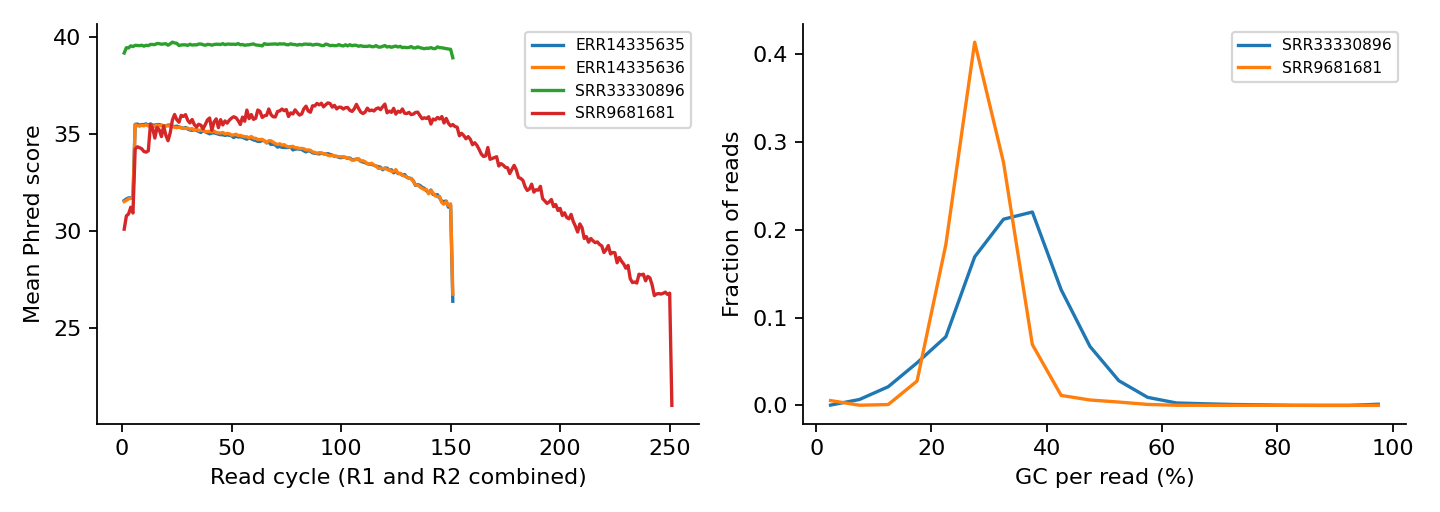

In [11]:
short_results = analyse_reads(RAW, OUT, RUNS, RAW / 'refs/panel.fasta', SHORT_LIMIT, LONG_LIMIT, 'short')
short_qc = pd.DataFrame(short_results['qc'])
display(short_qc[['run', 'reads', 'adapter_fraction', 'low_complexity_fraction', 'duplicate_fraction', 'polyg_fraction', 'trimmed_fraction', 'discarded_fraction']])
display(pd.DataFrame(short_results['pooled']))
B = pd.DataFrame(short_results['quality'])
G = pd.DataFrame(short_results['gc'])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for run, group in B.groupby('run'):
    axes[0].plot(group.cycle, group.mean_phred, label=run)
axes[0].set(xlabel='Read cycle (R1 and R2 combined)', ylabel='Mean Phred score')
axes[0].legend(fontsize=7)
for run, group in G.groupby('run'):
    if run in ['SRR9681681', 'SRR33330896']:
        axes[1].plot(100 * group.gc_mid, group['count'] / group['count'].sum(), label=run)
axes[1].set(xlabel='GC per read (%)', ylabel='Fraction of reads')
axes[1].legend(fontsize=7)
fig.tight_layout()
(OUT / 'figures').mkdir(exist_ok=True)
fig.savefig(OUT / 'figures/short_reads.png')
display(Image(filename=str(OUT / 'figures/short_reads.png')))
plt.close(fig)

An extra GC peak or poor mapping is a reason to investigate, not an organism identification. The NovaSeq example is associated with a plant host; plant nuclear DNA is a possible explanation for its poor mapping.

The two NextSeq runs share a study and release date, but a shared sequencing lane is unconfirmed. Without index reads and the original sample sheet, cross-sample assignments cannot uniquely identify index hopping. Zero assignments do not prove its absence.

## Task 5. Detect long-read artefacts

We use the first 2,000 reads from two ONT runs and one PacBio run (20 each in test mode). A chimera candidate needs one native and one foreign alignment, both with MAPQ>=20 and at least 300 query bases, with at most 50 bp overlap. The shared function above contains this condition in its `if long` branch.

ONT uses `map-ont`, and the PacBio Sequel IIe run uses `map-hifi`. Alignment differences include strain differences as well as sequencing errors. Same-organism rearrangements and organisms absent from the panel are outside this screen.

DRR504716 2000 reads; split candidates: 0


SRR6082028 2000 reads; split candidates: 0


SRR28122442 2000 reads; split candidates: 0


,run,reads,median_length,median_identity,foreign_native_splits
0,DRR504716,2000,2662.5,0.939701,0
1,SRR6082028,2000,8369.5,0.845600,0
2,SRR28122442,2000,3419.0,0.999532,0


/var/folders/nn/gc9nz98j7c97gxhglfhbdp_00000gn/T/ipykernel_52955/88538037.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Q = pd.concat([short_qc, long_qc]).set_index('run').loc[runs.run_accession].reset_index()


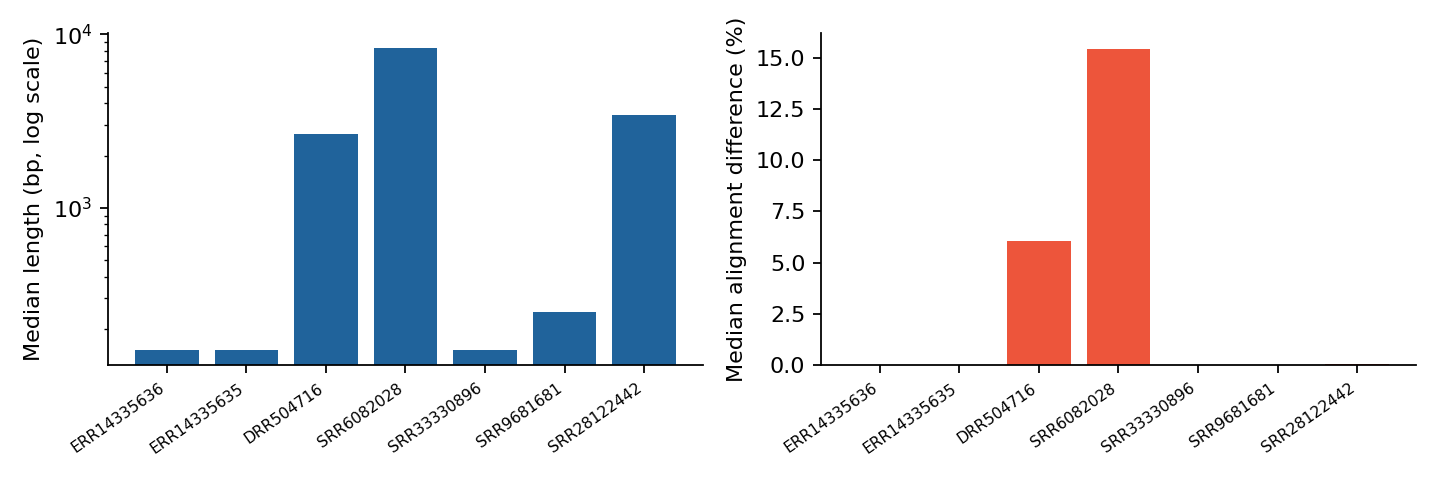

In [12]:
long_results = analyse_reads(RAW, OUT, RUNS, RAW / 'refs/panel.fasta', SHORT_LIMIT, LONG_LIMIT, 'long')
long_qc = pd.DataFrame(long_results['qc'])
display(long_qc[['run', 'reads', 'median_length', 'median_identity', 'foreign_native_splits']])
Q = pd.concat([short_qc, long_qc]).set_index('run').loc[runs.run_accession].reset_index()
Q.to_csv(OUT / 'read_qc.csv', index=False)
write_csv(OUT / 'read_gc.csv', short_results['gc'] + long_results['gc'])
write_csv(OUT / 'read_quality.csv', short_results['quality'])
write_csv(OUT / 'index_hopping.csv', short_results['pooled'], ['run', 'pairs', 'cross_sample_pairs', 'fraction'])
write_csv(OUT / 'chimeric_reads.csv', long_results['chimeras'], ['run', 'read', 'left', 'right', 'left_start', 'left_end', 'right_start', 'right_end'])
read_runtime = {'seconds': short_results['seconds'] + long_results['seconds'], 'peak_rss_os_units': max(short_results['peak_rss_os_units'], long_results['peak_rss_os_units'])}
(OUT / 'reads_runtime.json').write_text(json.dumps(read_runtime, indent=2))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
x = range(len(Q))
axes[0].bar(x, Q.median_length, color='#20639b')
axes[0].set_yscale('log')
axes[0].set_ylabel('Median length (bp, log scale)')
axes[1].bar(x, 100 * (1 - Q.median_identity), color='#ed553b')
axes[1].set_ylabel('Median alignment difference (%)')
for ax in axes:
    ax.set_xticks(list(x), Q.run, rotation=35, ha='right', fontsize=7)
fig.tight_layout()
fig.savefig(OUT / 'figures/platforms.png')
display(Image(filename=str(OUT / 'figures/platforms.png')))
plt.close(fig)

## Task 6. Identify foreign sequences with BLAST and score contamination versus HGT

We map every saved contig of at least 1 kb to the foreign panel and UniVec_Core with minimap2 (`mappy`, `asm5`). Retain matches with >=200 matching bases, >=95% identity and MAPQ>=20. Overlapping query intervals count only once; two rotated pieces of a circular reference can therefore cover one complete contig.

| Evidence | Points |
|---|---:|
| At least 80% of the contig covered | +2 |
| At least 98% identity | +1 |
| At least 12 percentage points of GC difference | +1 |
| At least 500 bases of flanking sequence on both sides | -3 |

A score >=3 marks a foreign candidate. Long flanks lead to an HGT/construct candidate if the score is below the threshold. Vector matches remain a separate category requiring review. This rule prioritises cases; it does not prove HGT or contamination.

In [13]:
def contamination_score(coverage, identity, gc_difference, long_flanks):
    score = 0
    if coverage >= 0.8:
        score += 2
    if identity >= 0.98:
        score += 1
    if gc_difference >= 0.12:
        score += 1
    if long_flanks:
        score -= 3
    return score

In [14]:
def align(out, panel, vectors):
    start = time.perf_counter()
    out = Path(out)
    panel_index = mappy.Aligner(str(panel), preset='asm5', best_n=3)
    vector_index = mappy.Aligner(str(vectors), preset='asm5', best_n=3)
    if not panel_index or not vector_index:
        raise RuntimeError('Reference index failed')
    meta = {r['qid']: r for r in read_csv(out / 'candidates.csv')}
    assemblies = {r['accession']: r for r in read_csv(out / 'assemblies.csv')}
    rows = []
    sequences = []
    for qid, seq, _ in mappy.fastx_read(str(out / 'candidates.fasta')):
        r = meta[qid]
        delta = float(r['gc_delta'])
        for category, index in [('Foreign', panel_index), ('Vector', vector_index)]:
            hits = [h for h in index.map(seq) if h.mlen >= 200 and h.mlen / max(1, h.blen) >= 0.95 and (h.mapq >= 20)]
            if not hits:
                continue
            by_target = {}
            for hit in hits:
                by_target.setdefault(hit.ctg, []).append(hit)
            group = max(by_target.values(), key=lambda hs: sum((h.mlen for h in hs)))
            h = max(group, key=lambda h: h.mlen)
            intervals = sorted(((h.q_st, h.q_en) for h in group))
            covered = 0
            stop = 0
            for st, en in intervals:
                covered += max(0, en - max(st, stop))
                stop = max(stop, en)
            left = min((st for st, en in intervals))
            right = max((en for st, en in intervals))
            ident = sum((h.mlen for h in group)) / sum((h.blen for h in group))
            cov = covered / len(seq)
            flanks = left >= 500 and len(seq) - right >= 500
            score = contamination_score(cov, ident, delta, flanks)
            status = 'suspect_contamination' if score >= 3 else 'HGT_or_construct_candidate' if flanks else 'uncertain'
            if category == 'Vector':
                status = 'vector_match_needs_review'
            rows.append(dict(accession=r['accession'], contig=r['contig'], category=category, start=left + 1, end=right, length=len(seq), identity=ident, coverage=cov, source=h.ctg, score=int(score), status=status, gc_delta=delta))
            if category == 'Foreign' and status == 'suspect_contamination':
                mid = (h.q_st + h.q_en) // 2
                s = max(h.q_st, mid - 500)
                e = min(h.q_en, s + 1000)
                sequences.append((r['accession'], r['contig'], seq[s:e], s + 1, e, len(seq)))
    write_csv(out / 'alignment_hits.csv', rows, ['accession', 'contig', 'category', 'start', 'end', 'length', 'identity', 'coverage', 'source', 'score', 'status', 'gc_delta'])
    sequences.sort(key=lambda r: (-r[5], r[0], r[1]))
    selected = []
    used = set()
    with (out / 'nt_queries.fasta').open('w') as f:
        for acc, cid, s, st, en, n in sequences:
            if acc in used:
                continue
            used.add(acc)
            qid = f'Q{len(selected) + 1:02d}'
            selected.append(dict(query=qid, accession=acc, contig=cid, start=st, end=en, length=n))
            f.write(f'>{qid}\n{s}\n')
            if len(selected) == 12:
                break
    write_csv(out / 'nt_queries.csv', selected)
    elapsed = time.perf_counter() - start
    (out / 'align_runtime.json').write_text(json.dumps({'seconds': elapsed, 'candidates': len(meta), 'peak_rss_os_units': resource.getrusage(resource.RUSAGE_SELF).ru_maxrss}, indent=2))
    print('Aligned', len(meta), 'contigs;', len(rows), 'panel/vector matches;', round(elapsed, 1), 'seconds', flush=True)

In [15]:
align(OUT, RAW / 'refs/panel.fasta', RAW / 'refs/UniVec_Core.fasta')
alignment_hits = pd.read_csv(OUT / 'alignment_hits.csv')
display(alignment_hits[alignment_hits.status == 'suspect_contamination'][['accession', 'contig', 'identity', 'coverage', 'score', 'source']])

Aligned 279354 contigs; 72 panel/vector matches; 80.2 seconds


,accession,contig,identity,coverage,score,source
17,GCA_013389495.1,JACAOE010000004.1,0.992377,1.0,4,GCF_000005845.2|Escherichia_coli|NC_000913.3
67,GCA_937885255.1,CALAAF010000019.1,1.000000,1.0,3,NC_005089.1|Mus_musculus_mitochondrion|NC_0050...
70,GCA_949083825.1,CARVPV010000123.1,1.000000,1.0,3,NC_005089.1|Mus_musculus_mitochondrion|NC_0050...


### NCBI BLAST identification
One 1 kb window per selected foreign candidate is searched with megablast, expectation threshold 1e-10 and up to 20 hits. Self-accession matches are excluded. Exact-query SHA-256 caches reproduce the original responses without another NCBI request. A new uncached query uses the live service in full mode; test mode requires the cache.

The request specifies `nt`; the saved response reports `core_nt`. That database excludes some large eukaryotic chromosomes. BLAST identifies a window, while the panel alignment provides whole-contig support.

In [16]:
URL = 'https://blast.ncbi.nlm.nih.gov/Blast.cgi'

def request(params):
    data = urllib.parse.urlencode(params).encode()
    with urllib.request.urlopen(urllib.request.Request(URL, data=data), timeout=180) as r:
        return r.read().decode()

In [17]:
def identify_with_blast(out, cache, offline):
    out = Path(out)
    if not read_csv(out / 'nt_queries.csv'):
        write_csv(out / 'nt_hits.csv', [], ['query', 'accession', 'contig', 'start', 'end', 'length', 'subject', 'organism', 'title', 'identity', 'query_coverage', 'evalue', 'bitscore', 'database', 'query_sha256'])
        return
    query = (out / 'nt_queries.fasta').read_text()
    digest = hashlib.sha256(query.encode()).hexdigest()
    cache = Path(cache)
    cache.mkdir(parents=True, exist_ok=True)
    result = cache / f'{digest}.json'
    stamp = cache / f'{digest}.request.json'
    if not result.exists():
        if offline:
            raise FileNotFoundError('No BLAST response for these exact queries')
        if stamp.exists():
            rid = json.loads(stamp.read_text())['rid']
        else:
            params = dict(CMD='Put', PROGRAM='blastn', DATABASE='nt', QUERY=query, MEGABLAST='on', HITLIST_SIZE=20, EXPECT='1e-10', tool='csi_genome_student_project', email='abylai0209@gmail.com')
            text = request(params)
            match = re.search('RID = (\\S+)', text)
            if not match:
                raise RuntimeError('NCBI did not return a BLAST request ID')
            rid = match.group(1)
            stamp.write_text(json.dumps(dict(rid=rid, query_sha256=digest, database_requested='nt', program='megablast', submitted_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())), indent=2))
        print('BLAST request:', rid, flush=True)
        for _ in range(30):
            time.sleep(60)
            status = request(dict(CMD='Get', FORMAT_OBJECT='SearchInfo', RID=rid))
            if 'Status=READY' in status:
                data = json.loads(request(dict(CMD='Get', FORMAT_TYPE='JSON2_S', RID=rid)))
                result.write_text(json.dumps(data))
                break
            if 'Status=FAILED' in status or 'Status=UNKNOWN' in status:
                raise RuntimeError('BLAST failed/expired: ' + rid)
        else:
            raise TimeoutError('BLAST still queued. Re-run to resume the same request.')
    data = json.loads(result.read_text())
    queries = {r['query']: r for r in read_csv(out / 'nt_queries.csv')}
    rows = []
    for item in data['BlastOutput2']:
        report = item['report']
        s = report['results']['search']
        qid = s['query_title'].split()[0]
        own = queries[qid]['contig'].split('.')[0]
        best = []
        for hit in s.get('hits', []):
            desc = next((d for d in hit['description'] if d.get('accession', '').split('.')[0] != own), None)
            if desc is None:
                continue
            h = max(hit['hsps'], key=lambda h: h['bit_score'])
            best.append(dict(**queries[qid], subject=desc.get('accession', ''), organism=desc.get('sciname', ''), title=desc.get('title', ''), identity=h['identity'] / h['align_len'], query_coverage=(h['query_to'] - h['query_from'] + 1) / s['query_len'], evalue=h['evalue'], bitscore=h['bit_score'], database=report['search_target'].get('db', ''), query_sha256=digest))
        if best:
            rows.append(max(best, key=lambda r: r['bitscore']))
        else:
            rows.append(dict(**queries[qid], subject='', organism='No non-self hit', title='', identity=0, query_coverage=0, evalue='', bitscore=0, database=report['search_target'].get('db', ''), query_sha256=digest))
    write_csv(out / 'nt_hits.csv', rows)
    print('Saved', len(rows), 'BLAST results', flush=True)

In [18]:
identify_with_blast(OUT, 'data/blast_cache', offline=MODE == 'test')
blast_hits = pd.read_csv(OUT / 'nt_hits.csv')
display(blast_hits[['accession', 'contig', 'organism', 'subject', 'identity', 'query_coverage', 'database']])

Saved 3 BLAST results


,accession,contig,organism,subject,identity,query_coverage,database
0,GCA_937885255.1,CALAAF010000019.1,Mus musculus,OW971656,1.000,1.0,core_nt
1,GCA_013389495.1,JACAOE010000004.1,Escherichia coli,OZ547145,0.999,1.0,core_nt
2,GCA_949083825.1,CARVPV010000123.1,Mus musculus,PV739045,1.000,1.0,core_nt


## Task 7. Audit thousands of records and estimate errors

Now we combine exact adapter flags and scored foreign matches. Vector and HGT/construct matches are counted separately. The same calculation produces rates by category, taxon, year and platform, keeping the number of assemblies in each group.

In full mode this is the 3,006-assembly audit. Test mode checks a selected miniature dataset and must not be interpreted as archive prevalence. Wilson intervals summarise count uncertainty; they do not correct sampling bias or missed contamination.

In [19]:
def interval(k, n):
    if not n:
        return [None, None]
    z = 1.96
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [max(0, mid - h), min(1, mid + h)]

In [20]:
A = assembly_stats.copy()
D = adapter_hits
V = alignment_hits
F = V[(V.category == 'Foreign') & (V.status == 'suspect_contamination')]
A['foreign'] = A.accession.isin(F.accession)
A['vector'] = A.accession.isin(V[V.category == 'Vector'].accession)
A['hgt'] = A.accession.isin(V[V.status == 'HGT_or_construct_candidate'].accession)
A['flagged'] = A.adapter | A.foreign
A['taxon'] = A.organism.str.replace('^(uncultured |Candidatus )+', '', regex=True).str.split().str[0].str.strip("'")
A.to_csv(OUT / 'assembly_flags.csv', index=False)
rate_rows = []
for grouping in ['year', 'era', 'platform', 'taxon']:
    for label, group in A.groupby(grouping, observed=True):
        for category in ['adapter', 'foreign', 'vector', 'hgt', 'flagged']:
            n = len(group)
            k = int(group[category].sum())
            low, high = interval(k, n)
            rate_rows.append({'grouping': grouping, 'group': label, 'category': category, 'n': n, 'flagged': k, 'rate': k / n, 'ci_low': low, 'ci_high': high})
rates = pd.DataFrame(rate_rows)
rates.to_csv(OUT / 'rates.csv', index=False)
summary = {'assemblies': len(A), 'contigs': int(A.contigs.sum()), 'bases': int(A.bp.sum()), 'adapter_assemblies': int(A.adapter.sum()), 'foreign_candidates': int(A.foreign.sum()), 'vector_candidates': int(A.vector.sum()), 'hgt_or_construct_candidates': int(A.hgt.sum()), 'flagged_assemblies': int(A.flagged.sum()), 'flag_rate': float(A.flagged.mean()), 'flag_rate_ci95': interval(int(A.flagged.sum()), len(A)), 'ani_failed': int((A.ani_status == 'Failed').sum()), 'direct_ena_links': len({row['assembly'] for row in links}), 'missing_platform': int((A.platform == 'Unknown').sum()), 'definition': 'Flagged = exact known adapter motif OR high-scoring foreign panel match. This is not proven contamination prevalence.'}
for name in ['scan', 'align', 'reads']:
    summary[name + '_runtime'] = json.loads((OUT / f'{name}_runtime.json').read_text())
(OUT / 'summary.json').write_text(json.dumps(summary, indent=2))
print(f"{summary['flagged_assemblies']} / {summary['assemblies']} flagged ({100 * summary['flag_rate']:.2f}%)")
for grouping in ['platform', 'taxon', 'year']:
    print(grouping)
    display(rates[(rates.grouping == grouping) & (rates.category == 'flagged')])

246 / 3006 flagged (8.18%)
platform


,grouping,group,category,n,flagged,rate,ci_low,ci_high
139,platform,Hybrid,flagged,111,0,0.000000,0.000000,0.033451
144,platform,Long,flagged,236,0,0.000000,0.000000,0.016017
149,platform,Short,flagged,2486,221,0.088898,0.078335,0.100729
154,platform,Unknown,flagged,173,25,0.144509,0.099836,0.204626


taxon


,grouping,group,category,n,flagged,rate,ci_low,ci_high
159,taxon,Acholeplasma,flagged,71,2,0.028169,0.007759,0.097017
164,taxon,Acholeplasmataceae,flagged,308,10,0.032468,0.017729,0.058725
169,taxon,Acholeplasmatales,flagged,80,5,0.062500,0.026989,0.138103
174,taxon,Alteracholeplasma,flagged,1,0,0.000000,0.000000,0.793457
179,taxon,Anaeroplasma,flagged,34,11,0.323529,0.191315,0.491574
...,...,...,...,...,...,...,...,...
519,taxon,Waltheria,flagged,1,0,0.000000,0.000000,0.793457
524,taxon,Williamsoniiplasma,flagged,7,0,0.000000,0.000000,0.354339
529,taxon,Xianfuyuplasma,flagged,4,0,0.000000,0.000000,0.489900
534,taxon,endosymbiont,flagged,2,0,0.000000,0.000000,0.657628


year


,grouping,group,category,n,flagged,rate,ci_low,ci_high
4,year,2004,flagged,1,0,0.000000,0.000000e+00,0.793457
9,year,2005,flagged,1,0,0.000000,0.000000e+00,0.793457
14,year,2006,flagged,1,0,0.000000,0.000000e+00,0.793457
19,year,2007,flagged,3,0,0.000000,0.000000e+00,0.561506
24,year,2008,flagged,2,0,0.000000,0.000000e+00,0.657628
29,year,2009,flagged,2,0,0.000000,0.000000e+00,0.657628
34,year,2010,flagged,3,0,0.000000,0.000000e+00,0.561506
39,year,2011,flagged,9,0,0.000000,0.000000e+00,0.299153
44,year,2012,flagged,7,3,0.428571,1.582169e-01,0.749546
49,year,2013,flagged,27,0,0.000000,6.938894e-18,0.124559


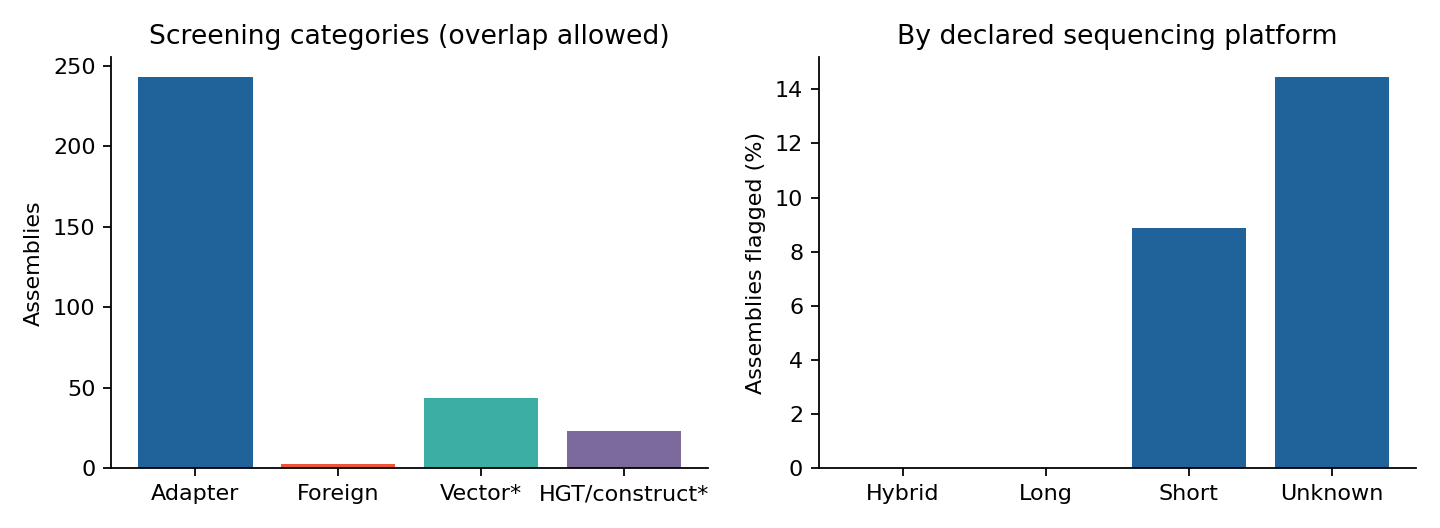

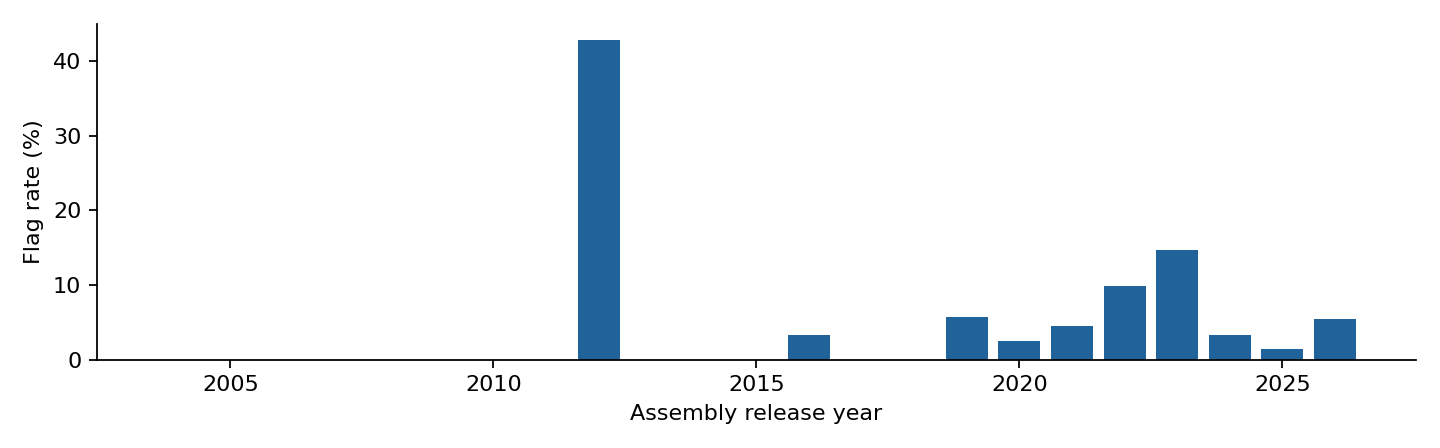

In [21]:
colours = ['#20639b', '#ed553b', '#3caea3', '#7c6a9c']
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
counts = [summary[key] for key in ['adapter_assemblies', 'foreign_candidates', 'vector_candidates', 'hgt_or_construct_candidates']]
axes[0].bar(['Adapter', 'Foreign', 'Vector*', 'HGT/construct*'], counts, color=colours)
axes[0].set(ylabel='Assemblies', title='Screening categories (overlap allowed)')
platform_rates = rates[(rates.grouping == 'platform') & (rates.category == 'flagged')]
axes[1].bar(platform_rates.group, 100 * platform_rates.rate, color=colours[0])
axes[1].set(ylabel='Assemblies flagged (%)', title='By declared sequencing platform')
fig.tight_layout()
fig.savefig(OUT / 'figures/archive.png')
display(Image(filename=str(OUT / 'figures/archive.png')))
plt.close(fig)
year_rates = rates[(rates.grouping == 'year') & (rates.category == 'flagged')]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(year_rates.group.astype(int), 100 * year_rates.rate, color=colours[0])
ax.set(xlabel='Assembly release year', ylabel='Flag rate (%)')
fig.tight_layout()
fig.savefig(OUT / 'figures/years.png')
display(Image(filename=str(OUT / 'figures/years.png')))
plt.close(fig)

### Random sample and case review
Use one representative hit per assembly, then a seeded random sample: up to 20 adapter assemblies, 10 vector assemblies and all three foreign candidates in this archive. The following cell retrieves nearby sequence and archive descriptions for inspection.

**Judgments are inputs, not automatic truth.** `config/review_annotations.csv` contains the recorded case-by-case verdicts and notes from the original review. We join them only to matching assembly, contig, category and coordinates. Unreviewed cases stay unresolved. The notebook regenerates evidence and calculates error estimates; it does not claim to perform a new independent human review. Reviewers can inspect `review_evidence.csv` and update the annotation table after checking a case.

In [22]:
sample_rows = []
for category, frame, limit in [('Adapter', D, 20), ('Vector', V[V.category == 'Vector'], 10), ('Foreign', F, 10)]:
    unique = frame.sort_values(['accession', 'contig', 'start']).drop_duplicates('accession')
    if len(unique):
        sample_rows.extend(unique.sample(n=min(limit, len(unique)), random_state=42).to_dict('records'))
sample = pd.DataFrame(sample_rows)
sample.to_csv(OUT / 'review_sample.csv', index=False)
metadata_records = {}
for file in sorted(Path('config').glob('mollicutes*.json')):
    for row in json.loads(file.read_text())['reports']:
        metadata_records[row['accession']] = row
wanted = set(sample.accession)
vector_headers = {line[1:].split()[0]: line[1:] for line in (RAW / 'refs/UniVec_Core.fasta').read_text().splitlines() if line.startswith('>')}
evidence = []
for accession, contigs in genomes(RAW):
    if accession not in wanted:
        continue
    sequences = dict(contigs)
    record = metadata_records.get(accession, {})
    info = record.get('assembly_info', {})
    for original in sample_rows:
        if original['accession'] != accession:
            continue
        row = original.copy()
        seq = sequences[row['contig']]
        start, end = (int(row['start']) - 1, int(row['end']))
        row.update(organism=record.get('organism', {}).get('organism_name', ''), bioproject=info.get('bioproject_accession', ''), strain=record.get('organism', {}).get('infraspecific_names', {}).get('strain', ''), title=info.get('biosample', {}).get('description', {}).get('title', ''), terminal_distance=min(start, len(seq) - end), context=seq[max(0, start - 30):min(len(seq), end + 30)] if row['category'] == 'Adapter' else '', reference_header=vector_headers.get(row['source'], ''))
        evidence.append(row)
evidence = pd.DataFrame(evidence)
evidence.to_csv(OUT / 'review_evidence.csv', index=False)
keys = ['accession', 'contig', 'category', 'start', 'end']
annotations = pd.read_csv('config/review_annotations.csv')
review = evidence.merge(annotations, on=keys, how='left', validate='one_to_one')
review['verdict'] = review.verdict.fillna('Unresolved')
review['review_note'] = review.review_note.fillna('No recorded review for this exact hit; inspect the evidence.')
review['review_method'] = 'case-by-case sequence-context and archive-annotation review; not independent experimental truth'
review.to_csv(OUT / 'review_decisions.csv', index=False)
display(review[['accession', 'category', 'terminal_distance', 'verdict', 'review_note']])

,accession,category,terminal_distance,verdict,review_note
0,GCA_000428705.1,Vector,2748,Unresolved,Match is an internal segment of a shuttle vect...
1,GCA_001267815.1,Vector,31568,False_contamination_label,BioSample explicitly describes a GM12 deletion...
2,GCA_010587055.1,Vector,638104,Unresolved,Short internal match to pmycYACTn in Spiroplas...
3,GCA_010587305.1,Vector,632862,Unresolved,Same short internal pmycYACTn match in another...
4,GCA_013389495.1,Foreign,0,Supported,"Whole 2,885 bp contig matches E. coli; indepen..."
5,GCA_017626915.1,Adapter,2,Supported,Reverse TruSeq motif starts two bases from the...
6,GCA_023254895.1,Adapter,19,Supported,TruSeq motif extends into the known GAACTCCAGT...
7,GCA_028685975.1,Adapter,1,Supported,Reverse read-2 adapter begins one base from th...
8,GCA_034005025.1,Adapter,1,Supported,Forward TruSeq motif ends one base before the ...
9,GCA_061231925.1,Adapter,5,Supported,Reverse TruSeq motif lies five bases from the ...


In [23]:
review_summary = {}
for category, group in review.groupby('category'):
    supported = int((group.verdict == 'Supported').sum())
    false = int((group.verdict == 'False_contamination_label').sum())
    unresolved = len(group) - supported - false
    resolved = supported + false
    review_summary[category] = {'reviewed': len(group), 'supported': supported, 'false': false, 'unresolved': unresolved, 'false_discovery_among_resolved': false / resolved if resolved else None, 'ci95': interval(false, resolved), 'all_sample_bounds': [false / len(group), (false + unresolved) / len(group)]}
(OUT / 'review_summary.json').write_text(json.dumps(review_summary, indent=2))
display(pd.DataFrame(review_summary).T)
display(pd.DataFrame([{'score_threshold': threshold, 'foreign_assemblies': V[(V.category == 'Foreign') & (V.score >= threshold)].accession.nunique()} for threshold in [2, 3, 4]]))
for row in long_qc.itertuples():
    print(row.run, 'split-read interval:', interval(int(row.foreign_native_splits), int(row.reads)))

,reviewed,supported,false,unresolved,false_discovery_among_resolved,ci95,all_sample_bounds
Adapter,20,19,0,1,0.0,"[0, 0.16818436536845052]","[0.0, 0.05]"
Foreign,3,3,0,0,0.0,"[0, 0.5615060804490177]","[0.0, 0.0]"
Vector,10,0,6,4,1.0,"[0.6096569663469354, 0.9999999999999999]","[0.6, 1.0]"


,score_threshold,foreign_assemblies
0,2,3
1,3,3
2,4,1


DRR504716 split-read interval: [0, 0.0019171176005129348]
SRR6082028 split-read interval: [0, 0.0019171176005129348]
SRR28122442 split-read interval: [0, 0.0019171176005129348]


The fraction of false labels among resolved flags is a **false-discovery fraction**, not a conventional false-positive rate over all clean genomes. The latter needs a representative clean truth set. In the full study, the 20 adapter reviews gave 19 supported and one unresolved; six of ten vector matches were consistent with intentional GM12 constructs, and four were unresolved. All three foreign candidates were supported, but this is a very small sample.

### Detector baseline and automatic checks
We use 100 real native 1 kb windows, then add a perfect adapter or an adapter with one changed base. These synthetic modifications test detector sensitivity and do not replace real archive data. Expected test-mode counts come from `data/test/expected.json`; full-mode counts are checked against the frozen report result.

In [24]:
pattern = re.compile('|'.join((s for motif in ADAPTERS.values() for s in (motif, rc(motif)))))
sequence = next((cs[0][1] for acc, cs in genomes('data/test') if acc == 'GCA_000008305.1'))
control = perfect = mutated = 0
motif = ADAPTERS['Nextera']
mutation = motif[:9] + ('A' if motif[9] != 'A' else 'C') + motif[10:]
for i in range(100):
    s = sequence[1000 * i:1000 * (i + 1)]
    control += bool(pattern.search(s))
    perfect += bool(pattern.search(s + motif))
    mutated += bool(pattern.search(s + mutation))
observed = dict(real_native_windows=100, native_flags=control, perfect_adapter_spikes_detected=perfect, single_mismatch_spikes_detected=mutated, spikes_per_condition=100)
assert control == 0 and perfect == 100
(OUT / 'adapter_benchmark.json').write_text(json.dumps(observed, indent=2))
display(pd.DataFrame([observed]))
if MODE == 'test':
    expected = json.loads(Path('data/test/expected.json').read_text())
else:
    expected = {'assemblies': 3006, 'flagged_assemblies': 246, 'adapter_assemblies': 243, 'foreign_candidates': 3}
for key, value in expected.items():
    assert summary[key] == value, (key, summary[key], value)
print('PASS: expected counts and adapter baseline agree.')

,real_native_windows,native_flags,perfect_adapter_spikes_detected,single_mismatch_spikes_detected,spikes_per_condition
0,100,0,100,0,100


PASS: expected counts and adapter baseline agree.


## Task 8. Prepare ten findings for a database curator

Select the longest foreign candidates (one per assembly), then adapter-rich assemblies until there are ten records. Coordinates are 1-based and inclusive. Adapter coordinates show one example; `adapter_hits.csv` contains all matches. In test mode fewer than ten findings may exist, so we return the available cases rather than inventing more.

Foreign candidates need BLAST, raw-read and assembly-context inspection before removal. For adapter cases, inspect terminal residues and internal joins. No sample swap or index-hopping event was demonstrated by this analysis.

In [25]:
top = []
for row in F.sort_values('length', ascending=False).drop_duplicates('accession').itertuples():
    top.append(dict(accession=row.accession, category='Foreign', contig=row.contig, start=row.start, end=row.end, evidence=f'{100 * row.identity:.2f}% identity; {100 * row.coverage:.1f}% contig covered; {row.source}', action='Inspect BLAST, raw-read support and assembly context; remove only if confirmed.'))
for acc, count in D.groupby('accession').size().sort_values(ascending=False).items():
    if len(top) >= 10:
        break
    if acc in {r['accession'] for r in top}:
        continue
    row = D[D.accession == acc].iloc[0]
    top.append(dict(accession=acc, category='Adapter', contig=row.contig, start=row.start, end=row.end, evidence=f'{count} exact adapter matches; example: {row.source}', action='Check listed coordinates; trim terminal adapter or inspect internal join.'))
write_csv(OUT / 'curator_top10.csv', top)
display(pd.DataFrame(top))
print('Evidence:', OUT / 'adapter_hits.csv', OUT / 'alignment_hits.csv', OUT / 'nt_hits.csv')
print('Saved', len(top), 'curator candidates.')

,accession,category,contig,start,end,evidence,action
0,GCA_937885255.1,Foreign,CALAAF010000019.1,1,16354,100.00% identity; 100.0% contig covered; NC_00...,"Inspect BLAST, raw-read support and assembly c..."
1,GCA_013389495.1,Foreign,JACAOE010000004.1,1,2885,99.24% identity; 100.0% contig covered; GCF_00...,"Inspect BLAST, raw-read support and assembly c..."
2,GCA_949083825.1,Foreign,CARVPV010000123.1,1,2163,100.00% identity; 100.0% contig covered; NC_00...,"Inspect BLAST, raw-read support and assembly c..."
3,GCA_900556265.1,Adapter,USOI01000001.1,1,19,568 exact adapter matches; example: Nextera,Check listed coordinates; trim terminal adapte...
4,GCA_900553385.1,Adapter,USDR01000001.1,33626,33644,445 exact adapter matches; example: Nextera,Check listed coordinates; trim terminal adapte...
5,GCA_937983315.1,Adapter,CALKAH010000001.1,23,43,337 exact adapter matches; example: TruSeq_R2,Check listed coordinates; trim terminal adapte...
6,GCA_947064695.1,Adapter,CAMSWF010000001.1,26,46,224 exact adapter matches; example: TruSeq,Check listed coordinates; trim terminal adapte...
7,GCA_948820955.1,Adapter,CAQKIL010000001.1,384,404,203 exact adapter matches; example: TruSeq,Check listed coordinates; trim terminal adapte...
8,GCA_949019015.1,Adapter,CARLZX010000001.1,17038,17058,196 exact adapter matches; example: TruSeq_R2,Check listed coordinates; trim terminal adapte...
9,GCA_948996125.1,Adapter,CARIPT010000002.1,16896,16916,174 exact adapter matches; example: TruSeq_R2,Check listed coordinates; trim terminal adapte...


Evidence: results/adapter_hits.csv results/alignment_hits.csv results/nt_hits.csv
Saved 10 curator candidates.


### Conclusion and limits
The full screen flags 246 of 3,006 assemblies (8.18%), mostly because of exact adapter motifs. Three foreign candidates match E. coli or mouse mitochondrial DNA. The four-reference panel, exact motif rule, prefix read sampling and incomplete metadata limit sensitivity. HGT, intended constructs and assembly mistakes can look similar. These are records to review, not a diagnosis of all contamination in the archive.

Both Abylaikhan Torekhan and Kuanysh Bakizhan worked on code and checked results. Both partners are responsible for the final report and explaining the analysis.

Sources: [NCBI VecScreen](https://www.ncbi.nlm.nih.gov/tools/vecscreen/interpretation/), [NCBI database scope](https://blast.ncbi.nlm.nih.gov/doc/blast-help/blastdatabases.html), [Illumina adapters](https://support-docs.illumina.com/SHARE/AdapterSequences/Content/Nextera_Illumina-Sequences.htm), [Salter et al.](https://doi.org/10.1186/s12915-014-0087-z), [Minimap2](https://doi.org/10.1093/bioinformatics/bty191).